Matplotlib is building the font cache; this may take a moment.


Image size: (960, 720)
Image mode: RGB
Mask size: (960, 720)
Mask mode: RGB


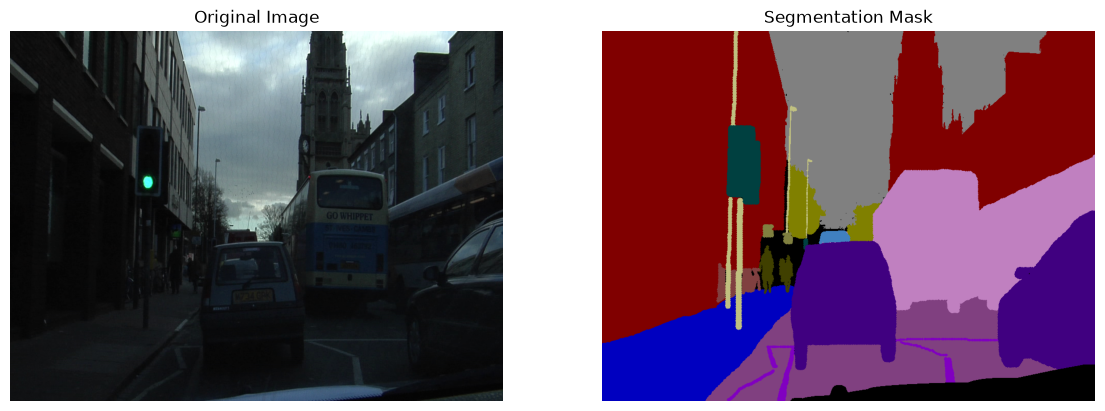

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "../data/raw/701_StillsRaw_full/0001TP_006690.png"
mask_path = "../data/raw/0001TP_006690_L.png"

image = Image.open(image_path)
mask = Image.open(mask_path)

print("Image size:", image.size)
print("Image mode:", image.mode)

print("Mask size:", mask.size)
print("Mask mode:", mask.mode)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(mask)
ax[1].set_title("Segmentation Mask")
ax[1].axis("off")

plt.show()

In [2]:
import numpy as np

mask_array = np.array(mask)

colors = np.unique(
    mask_array.reshape(-1, 3),
    axis=0
)

print("Number of unique colors:", len(colors))
print("\nRGB colors:")

for color in colors:
    print(tuple(color))

Number of unique colors: 15

RGB colors:
(np.uint8(0), np.uint8(0), np.uint8(0))
(np.uint8(0), np.uint8(0), np.uint8(192))
(np.uint8(0), np.uint8(64), np.uint8(64))
(np.uint8(64), np.uint8(0), np.uint8(128))
(np.uint8(64), np.uint8(64), np.uint8(0))
(np.uint8(64), np.uint8(128), np.uint8(192))
(np.uint8(128), np.uint8(0), np.uint8(0))
(np.uint8(128), np.uint8(0), np.uint8(192))
(np.uint8(128), np.uint8(64), np.uint8(64))
(np.uint8(128), np.uint8(64), np.uint8(128))
(np.uint8(128), np.uint8(128), np.uint8(0))
(np.uint8(128), np.uint8(128), np.uint8(64))
(np.uint8(128), np.uint8(128), np.uint8(128))
(np.uint8(192), np.uint8(128), np.uint8(192))
(np.uint8(192), np.uint8(192), np.uint8(128))


In [3]:
from pathlib import Path
from PIL import Image
import numpy as np

label_dir = Path("../data/raw")

all_colors = set()

for mask_path in label_dir.glob("*_L.png"):
    mask_array = np.array(Image.open(mask_path))
    colors = np.unique(mask_array.reshape(-1, 3), axis=0)

    for color in colors:
        all_colors.add(tuple(color))

print("Total unique RGB colors in all masks:", len(all_colors))

for color in sorted(all_colors):
    print(color)

Total unique RGB colors in all masks: 86
(np.uint8(0), np.uint8(0), np.uint8(0))
(np.uint8(0), np.uint8(0), np.uint8(64))
(np.uint8(0), np.uint8(0), np.uint8(192))
(np.uint8(0), np.uint8(64), np.uint8(64))
(np.uint8(0), np.uint8(128), np.uint8(64))
(np.uint8(0), np.uint8(128), np.uint8(192))
(np.uint8(2), np.uint8(2), np.uint8(0))
(np.uint8(2), np.uint8(2), np.uint8(2))
(np.uint8(5), np.uint8(5), np.uint8(0))
(np.uint8(8), np.uint8(8), np.uint8(8))
(np.uint8(15), np.uint8(15), np.uint8(15))
(np.uint8(18), np.uint8(18), np.uint8(0))
(np.uint8(26), np.uint8(26), np.uint8(0))
(np.uint8(26), np.uint8(26), np.uint8(26))
(np.uint8(29), np.uint8(29), np.uint8(0))
(np.uint8(36), np.uint8(36), np.uint8(36))
(np.uint8(47), np.uint8(47), np.uint8(0))
(np.uint8(48), np.uint8(48), np.uint8(0))
(np.uint8(48), np.uint8(48), np.uint8(48))
(np.uint8(50), np.uint8(50), np.uint8(0))
(np.uint8(50), np.uint8(50), np.uint8(50))
(np.uint8(51), np.uint8(51), np.uint8(0))
(np.uint8(51), np.uint8(51), np.uint8(

In [4]:
from collections import Counter
import numpy as np

mask_array = np.array(mask)

pixels = mask_array.reshape(-1, 3)

color_counts = Counter(map(tuple, pixels))

print("Top 20 colors in this mask:")

for color, count in color_counts.most_common(20):
    percentage = count / len(pixels) * 100
    print(color, f"{percentage:.2f}%")

Top 20 colors in this mask:
(np.uint8(128), np.uint8(0), np.uint8(0)) 37.48%
(np.uint8(128), np.uint8(128), np.uint8(128)) 13.77%
(np.uint8(192), np.uint8(128), np.uint8(192)) 11.76%
(np.uint8(64), np.uint8(0), np.uint8(128)) 11.73%
(np.uint8(128), np.uint8(64), np.uint8(128)) 8.67%
(np.uint8(0), np.uint8(0), np.uint8(192)) 6.85%
(np.uint8(0), np.uint8(0), np.uint8(0)) 4.14%
(np.uint8(128), np.uint8(128), np.uint8(0)) 1.34%
(np.uint8(0), np.uint8(64), np.uint8(64)) 1.34%
(np.uint8(192), np.uint8(192), np.uint8(128)) 1.10%
(np.uint8(128), np.uint8(0), np.uint8(192)) 0.66%
(np.uint8(128), np.uint8(64), np.uint8(64)) 0.44%
(np.uint8(64), np.uint8(64), np.uint8(0)) 0.43%
(np.uint8(64), np.uint8(128), np.uint8(192)) 0.18%
(np.uint8(128), np.uint8(128), np.uint8(64)) 0.13%


In [5]:
official_colors = {
    (128, 128, 128),
    (0, 128, 64),
    (128, 0, 0),
    (64, 192, 0),
    (64, 0, 64),
    (192, 0, 128),
    (192, 192, 128),
    (0, 0, 64),
    (128, 64, 128),
    (128, 0, 192),
    (192, 0, 64),
    (0, 0, 192),
    (64, 192, 128),
    (128, 128, 192),
    (128, 128, 0),
    (192, 128, 128),
    (64, 64, 128),
    (192, 192, 0),
    (64, 0, 128),
    (64, 64, 0),
    (192, 128, 64),
    (0, 128, 192),
    (0, 128, 0),
    (128, 192, 0),
    (0, 64, 64),
    (64, 64, 0),
    (192, 192, 128),
}

actual_colors = set(map(tuple, pixels))

unknown_colors = actual_colors - official_colors

print("Colors not in our official-color set:", len(unknown_colors))
print(sorted(unknown_colors))

Colors not in our official-color set: 5
[(np.uint8(0), np.uint8(0), np.uint8(0)), (np.uint8(64), np.uint8(128), np.uint8(192)), (np.uint8(128), np.uint8(64), np.uint8(64)), (np.uint8(128), np.uint8(128), np.uint8(64)), (np.uint8(192), np.uint8(128), np.uint8(192))]
